# Phase 3 – Random Forest

**Ziel:** Random Forest trainieren, mit Poisson-Baseline vergleichen,
Feature Importance plotten und Modell als `models/ems_forecast_rf_v1.pkl` speichern.

**Voraussetzungen:** Phase 1 + Phase 2 müssen abgeschlossen sein.

In [1]:
import sys
import warnings
from pathlib import Path
from math import sqrt
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLUMNS, GEBIET_NAMES, build_feature_row, count_to_risk_level

print('Imports OK')

Imports OK


## 3.1 – Daten laden & Split

In [2]:
df = joblib.load(ROOT / 'models' / 'features_aggregated.pkl')
print(f'Shape: {df.shape}')

TARGET = 'einsatz_count'
X = df[FEATURE_COLUMNS]
y = df[TARGET]

# Gleicher random_state wie Baseline → direkt vergleichbar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Shape: (33437, 9)
Train: (26749, 7)  |  Test: (6688, 7)


## 3.2 – Random Forest trainieren

In [3]:
# Hyperparameter exakt wie in AGENT.md vorgegeben
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Training abgeschlossen.')
print(f'Anzahl Bäume: {rf.n_estimators}  |  Features: {rf.n_features_in_}')

Training abgeschlossen.
Anzahl Bäume: 200  |  Features: 7


## 3.3 – Metriken & Vergleich mit Baseline

In [4]:
y_pred_rf = rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# Baseline-Metriken aus Phase 2 laden
baseline_path = ROOT / 'models' / 'baseline_metrics.pkl'
if baseline_path.exists():
    bm = joblib.load(baseline_path)
    mae_b, rmse_b, r2_b = bm['MAE'], bm['RMSE'], bm['R2']
else:
    mae_b = rmse_b = r2_b = float('nan')
    print('Warnung: baseline_metrics.pkl nicht gefunden – Baseline-Werte fehlen.')

header = f'{"Modell":<22} {"MAE":>8} {"RMSE":>8} {"R²":>8}'
sep    = '-' * len(header)
print(sep)
print(header)
print(sep)
print(f'{"Poisson (Baseline)":<22} {mae_b:>8.4f} {rmse_b:>8.4f} {r2_b:>8.4f}')
print(f'{"Random Forest":<22} {mae_rf:>8.4f} {rmse_rf:>8.4f} {r2_rf:>8.4f}')
print(sep)

if mae_rf < mae_b:
    print(f'\n✅ Random Forest besser als Baseline (MAE {mae_rf:.4f} < {mae_b:.4f})')
else:
    print(f'\n⚠ Random Forest schlechter als Baseline (MAE {mae_rf:.4f} ≥ {mae_b:.4f})')

-------------------------------------------------
Modell                      MAE     RMSE       R²
-------------------------------------------------
Poisson (Baseline)       0.2396   0.3828   0.0021
Random Forest            0.2462   0.4088  -0.1377
-------------------------------------------------

⚠ Random Forest schlechter als Baseline (MAE 0.2462 ≥ 0.2396)


## 3.4 – Feature Importance

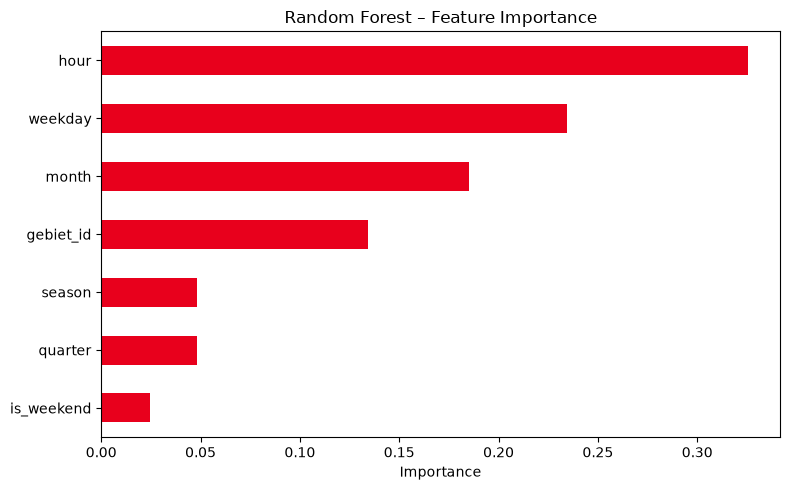

Plot gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\output\feature_importance.png


In [5]:
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color='#E8001C')
ax.set_title('Random Forest – Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()

plot_path = OUTPUT_DIR / 'feature_importance.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot gespeichert: {plot_path}')

## 3.5 – Modell speichern

In [6]:
MODELS_DIR = ROOT / 'models'
model_path = MODELS_DIR / 'ems_forecast_rf_v1.pkl'
joblib.dump(rf, model_path)

size_kb = model_path.stat().st_size / 1024
print(f'Modell gespeichert: {model_path}')
print(f'Dateigröße: {size_kb:.1f} KB')

Modell gespeichert: C:\Users\lholz\OneDrive\Desktop\Diplomarbeit\RKA_RotKreuzApp\Modell\models\ems_forecast_rf_v1.pkl
Dateigröße: 95533.1 KB


## 3.6 – Einzelvorhersage testen: Gebiet 1 (Linz), Mittwoch 14 Uhr, Juli

In [7]:
# Testvorhersage für Linz, Mittwoch 14:00 Uhr im Juli
# Mittwoch = weekday 2, kein Wochenende, Juli = Sommer (season=2)
test_dt = datetime(2025, 7, 2, 14, 0)  # 2025-07-02 ist ein Mittwoch
feature_row = build_feature_row(gebiet_id=1, dt=test_dt)
X_single = pd.DataFrame([feature_row])[FEATURE_COLUMNS]

predicted = float(rf.predict(X_single)[0])
predicted = max(0.0, predicted)

# Maximalwert des Gebiets 1 aus den Trainingsdaten
max_g1 = float(y_train[X_train['gebiet_id'] == 1].max()) if (X_train['gebiet_id'] == 1).any() else 10.0
risk = count_to_risk_level(predicted, max_g1)

print(f'Gebiet: {GEBIET_NAMES[1]} (ID 1)')
print(f'Zeitpunkt: {test_dt.strftime("%A %d.%m.%Y %H:%M")} Uhr')
print(f'Feature-Vektor: {feature_row}')
print(f'\nVorhergesagte Einsätze: {predicted:.2f}')
print(f'Risikostufe:             {risk} / 5  (Max-Referenz: {max_g1:.1f})')

Gebiet: Linz (ID 1)
Zeitpunkt: Wednesday 02.07.2025 14:00 Uhr
Feature-Vektor: {'gebiet_id': 1, 'hour': 14, 'weekday': 2, 'month': 7, 'quarter': 3, 'is_weekend': 0, 'season': 2}

Vorhergesagte Einsätze: 1.13
Risikostufe:             2 / 5  (Max-Referenz: 5.0)


---
## ✅ Phase 3 abgeschlossen
- Random Forest mit Baseline verglichen
- `models/ems_forecast_rf_v1.pkl` gespeichert
- Feature-Importance-Plot unter `output/feature_importance.png`